<a href="https://colab.research.google.com/github/MatteoBaraldi/Machine-Learning-for-Bioengineering/blob/main/exercises/Template_Module_1_20240702.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Do not modify the next code cell

In [96]:
import numpy as np

# Generate Synthetic Data
np.random.seed(42)
n_samples = 200
n_features = 10

# Features are random values
X = np.random.rand(n_samples, n_features)

# Target variable is a linear combination of features with some noise
true_coefficients = np.random.rand(n_features)
y = X @ true_coefficients + np.random.normal(scale=0.5, size=n_samples)


Place below your code

In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_validate, KFold
from sklearn.svm import SVR

# 2. Implement-Cross Validation


In [105]:
n_repeats = 10
n_folds = 5
iteration_mae = []

for i in range(n_repeats):
    cv = KFold(n_splits=n_folds, shuffle=True, random_state=42 + i)
    reg = LinearRegression()

    score = cross_validate(reg, X, y, cv=cv, scoring='neg_mean_absolute_error', return_train_score=True)

    mean_mae = np.mean(np.abs(score['test_score']))
    iteration_mae.append(mean_mae)

    print("Average MAE training set:", np.mean(np.abs(score['train_score'])), "years")
    print("Average MAE test set:", np.mean(np.abs(score['test_score'])), "years")


Average MAE training set: 0.3769017548047314 years
Average MAE test set: 0.4011701540389927 years
Average MAE training set: 0.37753713911517117 years
Average MAE test set: 0.40488329239524096 years
Average MAE training set: 0.3774955280297297 years
Average MAE test set: 0.40646471412425444 years
Average MAE training set: 0.37680271439961127 years
Average MAE test set: 0.3945540111728577 years
Average MAE training set: 0.3783385337666922 years
Average MAE test set: 0.39443866012084444 years
Average MAE training set: 0.3774108342359429 years
Average MAE test set: 0.40196973029391775 years
Average MAE training set: 0.37697362995562045 years
Average MAE test set: 0.4020149733734738 years
Average MAE training set: 0.3764292085596801 years
Average MAE test set: 0.39911091096410456 years
Average MAE training set: 0.37644153040993045 years
Average MAE test set: 0.3952271631483864 years
Average MAE training set: 0.3748523813627938 years
Average MAE test set: 0.4132353265603322 years


### 3. Calculate and Plot results

Overall average MAE: 0.4013


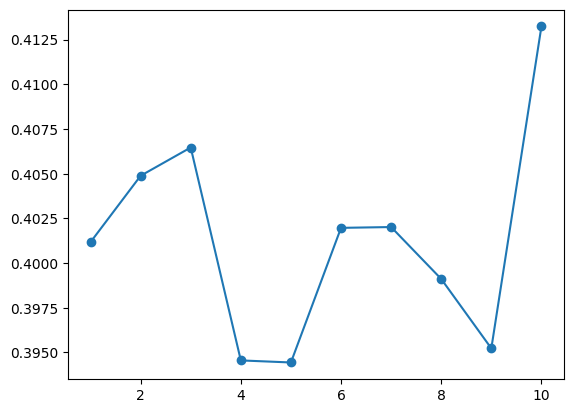

In [106]:
overall_mean_mae = np.mean(iteration_mae)
print(f"Overall average MAE: {overall_mean_mae:.4f}")

plt.plot(range(1, n_repeats + 1), iteration_mae, marker='o')

### 4. ANALYISIS

Repeating cross-validation is important because a single k-fold run depends entirely on how the data was randomly shuffled. By running the process multiple times with different shuffles, you minimize the impact of partitioning noise and outliers that might have skewed a single iteration, this repetition reveals the true variability.